<a href="https://colab.research.google.com/github/namithashaji/Clustering-Iris-Dataset/blob/main/Clustering_Iris_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Clustering - Iris Dataset

In [205]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [206]:
# Load Dataset
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [207]:
# Data Preprocessing
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# K-Means Clustering

K-means clustering is an unsupervised machine learning algorithm used to group similar data points into clusters.

How it works:

1. Choose the number of clusters K.
2. Randomly initialize K centroids (cluster centers).
3. Assign each data point to the nearest centroid using distance measures such as Euclidean distance.
4. Recalculate the centroid of each cluster based on the assigned points.
5. Repeat the assignment and update steps until the centroids no longer change significantly.

KMeans is suitable for Iris dataset because:

* The dataset naturally contains three flower species, which can correspond to K = 3 clusters.
* The numerical features are continuous and well-suited for distance-based clustering.
* Some species in the dataset form clearly separable groups, making clustering effective.
* KMeans is simple, fast, and works well for small structured datasets like Iris.

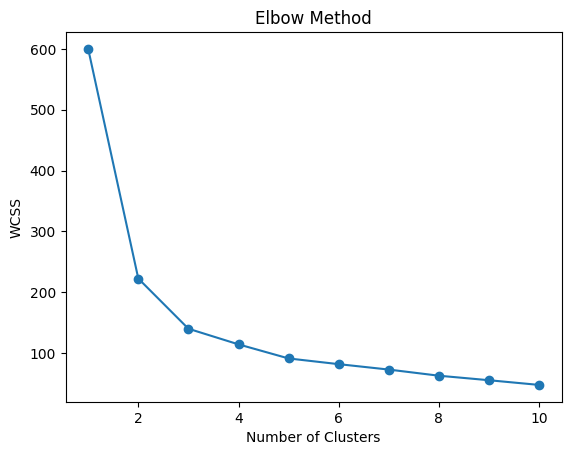

In [208]:
#Finding optimal k using elbow method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

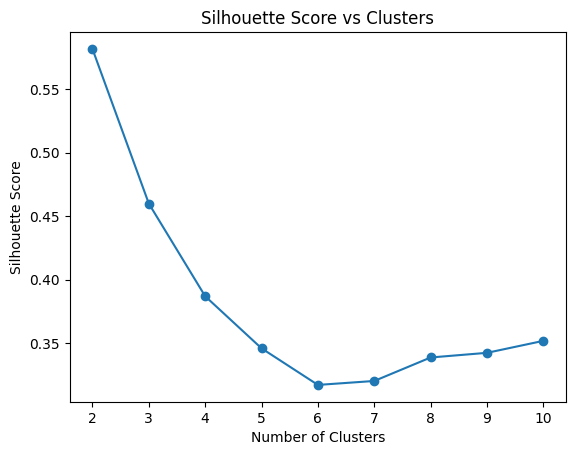

In [209]:
#Finding optimal k using Silhouette Score
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)

plt.figure()
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score vs Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [210]:
# Model Training
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


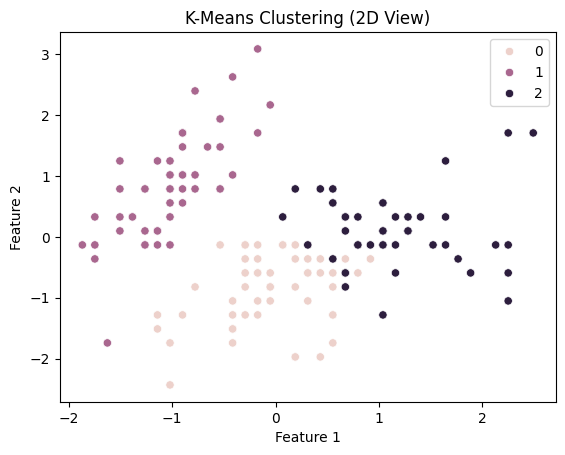

In [211]:
plt.figure()
sns.scatterplot(
    x=scaled_data[:, 0],
    y=scaled_data[:, 1],
    hue=clusters
)

plt.title('K-Means Clustering (2D View)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## Hierarchical Clustering (DBSCAN)

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised clustering algorithm that groups data points based on density.

How it works:

Select two parameters:
1. Epsilon (ε): maximum distance between neighboring points.
2. MinPts: minimum number of points needed to form a dense region.

* Points in dense regions are grouped into clusters.
* Points that do not belong to any dense region are treated as noise or outliers.

DBSCAN is suitable for the Iris dataset because:

* It can automatically detect clusters without predefining the number of clusters.
* It handles noise and outliers effectively.
* It can discover clusters even when boundaries between species are not perfectly separated.
* It works well for exploratory analysis of small datasets like Iris.

In [212]:
# Initialize DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=8)

# Fit and predict
labels = dbscan.fit_predict(scaled_data)

print("Unique Labels:", set(labels))

Unique Labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}


In [213]:
#Find Silhouette Score
mask = labels != -1

if len(set(labels)) > 1 and sum(mask) > 0:
    score = silhouette_score(scaled_data[mask], labels[mask])
    print("Silhouette Score:", score)
else:
    print("Not enough clusters to evaluate")

Silhouette Score: 0.6028694923383574


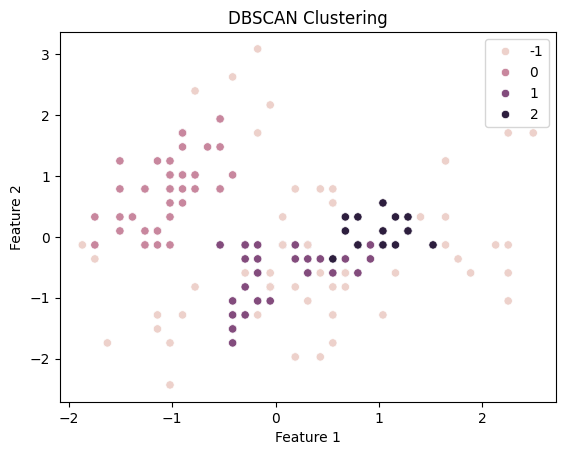

In [214]:
plt.figure()
sns.scatterplot(
    x=scaled_data[:, 0],
    y=scaled_data[:, 1],
    hue=labels
)
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Points in figure labeled as -1 are noise (outliers)